# Random Forest Regression on Walmart Weekly Sales - Technical Paper Version
This notebook implements a rigorous Random Forest Regression analysis suitable for academic/technical papers:
1) Loading and preprocessing the Walmart sales dataset
2) Feature engineering with domain knowledge
3) 60% validation, 20% training, 20% test split
4) **Systematic hyperparameter optimization** using cross-validation
5) Comprehensive evaluation on train, validation, and test sets
6) Metrics reported in interpretable units (dollars)

**Random Forest Regression:**
- **Ensemble model** - combines predictions from multiple decision trees
- **More robust than single Decision Tree** - less prone to overfitting
- Makes predictions by averaging predictions from all trees in the forest
- **Key hyperparameters**: n_estimators, max_depth, min_samples_split, min_samples_leaf
- **Typically achieves higher R² than Decision Trees and Linear models**
- Hyperparameters optimized via 5-fold cross-validation
- **No scaling required** (tree-based models are scale-invariant)

In [1]:
# 1) Imports and reproducibility
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

np.random.seed(42)  # reproducibility

In [2]:
# 2) Load the dataset and parse dates safely
# Try local relative path first; if it fails, try the Downloads path
csv_candidates = [
    'walmart-sales-dataset-of-45stores.csv',
    '/Users/jaacabrera/Downloads/walmart-sales-dataset-of-45stores.csv',
]

df = None
for p in csv_candidates:
    try:
        df = pd.read_csv(p, low_memory=False)
        print(f'Loaded: {p}')
        break
    except Exception:
        pass

if df is None:
    raise FileNotFoundError('Could not find the dataset. Update the path in csv_candidates.')

# Parse Date with day-first format (file has dd-mm-yyyy like '19-02-2010')
df['Date'] = pd.to_datetime(df['Date'].astype('string'), errors='coerce', dayfirst=True)
bad_dates = df['Date'].isna().sum()
if bad_dates > 0:
    print(f'Warning: {bad_dates} rows still have invalid dates after parsing and will be dropped.')
    df = df.dropna(subset=['Date']).reset_index(drop=True)

# Drop rows with missing target just in case
if 'Weekly_Sales' not in df.columns:
    raise KeyError('Weekly_Sales column not found. Check your CSV headers.')
df = df.dropna(subset=['Weekly_Sales']).reset_index(drop=True)

print(f'Data shape after date/target checks: {df.shape}')
df.head(3)

Loaded: walmart-sales-dataset-of-45stores.csv
Data shape after date/target checks: (6435, 8)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106


In [3]:
# 3) Create simple, beginner-friendly features (no leakage from the target)
# Date-derived features
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date'].dt.quarter
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

# Store encoded as numeric (already numeric in this dataset)
if 'Store' in df.columns:
    df['Store_Encoded'] = df['Store']
else:
    df['Store_Encoded'] = 0  # fallback if missing

# Choose a small, readable feature set for Random Forest Regression
feature_cols = [
    'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'Store_Encoded', 'Month', 'DayOfWeek', 'Week', 'Quarter', 'IsWeekend'
]

# Build X (features) and y (target)
X = df[feature_cols].copy()
y = df['Weekly_Sales'].copy()

print('X shape:', X.shape, '| y shape:', y.shape)
print('Features:', feature_cols)

X shape: (6435, 11) | y shape: (6435,)
Features: ['Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Store_Encoded', 'Month', 'DayOfWeek', 'Week', 'Quarter', 'IsWeekend']


In [4]:
# 4) Split into 60% validation, 20% training, 20% test (as requested)
# Stage 1: 20% test holdout
X_rem, X_test, y_rem, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Stage 2: Of the remaining 80%, use 25% for training (overall 20%) and 75% for validation (overall 60%)
X_train, X_val, y_train, y_val = train_test_split(X_rem, y_rem, train_size=0.25, random_state=42)

print(f'Split sizes -> train: {len(X_train)} ({len(y_train)/len(y):.0%}), '
      f'val: {len(X_val)} ({len(y_val)/len(y):.0%}), '
      f'test: {len(X_test)} ({len(y_test)/len(y):.0%})')

Split sizes -> train: 1287 (20%), val: 3861 (60%), test: 1287 (20%)


In [5]:
# 5) Systematic hyperparameter optimization using cross-validation
# This is the rigorous approach for technical papers

imputer = SimpleImputer(strategy='median')

# Fit imputer on TRAIN only, then apply to VAL/TEST (prevents data leakage)
# NOTE: Random Forest doesn't require scaling!
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_cols)
X_val_imp   = pd.DataFrame(imputer.transform(X_val), columns=feature_cols)
X_test_imp  = pd.DataFrame(imputer.transform(X_test), columns=feature_cols)

# Hyperparameter tuning: Search multiple hyperparameters systematically
print("Performing 5-fold cross-validation to find optimal hyperparameters...")
print("Tuning: n_estimators, max_depth, min_samples_split, min_samples_leaf")
print("This may take several minutes (Random Forest trains multiple trees)...\n")

param_grid = {
    'n_estimators': [50, 100, 200],           # Number of trees in the forest
    'max_depth': [10, 20, None],              # Tree depth
    'min_samples_split': [2, 10],             # Minimum samples to split a node
    'min_samples_leaf': [1, 5]                # Minimum samples in a leaf node
}

rf_cv = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1), 
    param_grid, 
    cv=5,  # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
rf_cv.fit(X_train_imp, y_train)

# Extract best model and parameters
rf = rf_cv.best_estimator_
best_params = rf_cv.best_params_
cv_score = rf_cv.best_score_

print(f"\n{'='*70}")
print(f"CROSS-VALIDATION RESULTS")
print(f"{'='*70}")
print(f"Best n_estimators: {best_params['n_estimators']}")
print(f"Best max_depth: {best_params['max_depth']}")
print(f"Best min_samples_split: {best_params['min_samples_split']}")
print(f"Best min_samples_leaf: {best_params['min_samples_leaf']}")
print(f"CV R² score (5-fold): {cv_score:.4f}")
print(f"{'='*70}\n")

# Predict on all sets
preds_train = rf.predict(X_train_imp)
preds_val = rf.predict(X_val_imp)
preds_test = rf.predict(X_test_imp)

# Calculate metrics
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

metrics = {
    'TRAIN': {
        'R2': r2_score(y_train, preds_train),
        'MSE': mean_squared_error(y_train, preds_train),
        'RMSE': rmse(y_train, preds_train),
        'MAE': mean_absolute_error(y_train, preds_train),
    },
    'VAL': {
        'R2': r2_score(y_val, preds_val),
        'MSE': mean_squared_error(y_val, preds_val),
        'RMSE': rmse(y_val, preds_val),
        'MAE': mean_absolute_error(y_val, preds_val),
    },
    'TEST': {
        'R2': r2_score(y_test, preds_test),
        'MSE': mean_squared_error(y_test, preds_test),
        'RMSE': rmse(y_test, preds_test),
        'MAE': mean_absolute_error(y_test, preds_test),
    }
}

print('Random Forest Regression Performance (hyperparameters optimized via CV)')
print(f"  Train Metrics       -> R²: {metrics['TRAIN']['R2']:.4f} | RMSE: ${metrics['TRAIN']['RMSE']:,.2f} | MAE: ${metrics['TRAIN']['MAE']:,.2f}")
print(f"  Validation Metrics  -> R²: {metrics['VAL']['R2']:.4f} | RMSE: ${metrics['VAL']['RMSE']:,.2f} | MAE: ${metrics['VAL']['MAE']:,.2f}")
print(f"  Test Metrics        -> R²: {metrics['TEST']['R2']:.4f} | RMSE: ${metrics['TEST']['RMSE']:,.2f} | MAE: ${metrics['TEST']['MAE']:,.2f}")
print(f"\n  ► Test set R² = {metrics['TEST']['R2']:.4f} (PRIMARY RESULT for papers)")

# Check for overfitting
train_val_diff = metrics['TRAIN']['R2'] - metrics['VAL']['R2']
if train_val_diff > 0.1:
    print(f"\n  ⚠ Warning: Possible overfitting detected (Train R² - Val R² = {train_val_diff:.4f})")
    print(f"     Consider reducing max_depth or increasing min_samples_split/leaf")
else:
    print(f"\n  ✓ Model generalization looks good (Train R² - Val R² = {train_val_diff:.4f})")

# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n  ► Top 5 Most Important Features:")
for idx, row in feature_importance.head(5).iterrows():
    print(f"     {row['Feature']:20s}: {row['Importance']:.4f}")

# Export metrics summary to CSV
metrics_df = pd.DataFrame({
    'Dataset': ['Train', 'Validation', 'Test'],
    'R²': [metrics['TRAIN']['R2'], metrics['VAL']['R2'], metrics['TEST']['R2']],
    'MSE': [metrics['TRAIN']['MSE'], metrics['VAL']['MSE'], metrics['TEST']['MSE']],
    'RMSE': [metrics['TRAIN']['RMSE'], metrics['VAL']['RMSE'], metrics['TEST']['RMSE']],
    'MAE': [metrics['TRAIN']['MAE'], metrics['VAL']['MAE'], metrics['TEST']['MAE']]
})

output_file = 'RandomForest_Regression_Metrics.csv'
metrics_df.to_csv(output_file, index=False)
print(f'\n✓ Metrics saved to: {output_file}')

# Export hyperparameters summary to CSV
hyperparams_df = pd.DataFrame({
    'Hyperparameter': ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'random_state', 'cv_folds', 'cv_r2_score'],
    'Value': [best_params['n_estimators'], best_params['max_depth'], best_params['min_samples_split'], best_params['min_samples_leaf'], rf.random_state, 5, cv_score],
    'Tuned': ['Yes (GridSearchCV)', 'Yes (GridSearchCV)', 'Yes (GridSearchCV)', 'Yes (GridSearchCV)', 'No (fixed)', 'N/A', 'N/A'],
    'Description': [
        'Number of trees in the forest',
        'Maximum depth of each tree',
        'Minimum samples required to split a node',
        'Minimum samples required in a leaf node',
        'Random seed for reproducibility',
        'Number of cross-validation folds',
        'Best R² score from cross-validation'
    ]
})

hyperparams_file = 'RandomForest_Hyperparameters.csv'
hyperparams_df.to_csv(hyperparams_file, index=False)
print(f'✓ Hyperparameters saved to: {hyperparams_file}')

# Export feature importances to CSV
feature_importance_file = 'RandomForest_Feature_Importances.csv'
feature_importance.to_csv(feature_importance_file, index=False)
print(f'✓ Feature importances saved to: {feature_importance_file}')

# Export actual vs predicted values for manual Excel verification
# Train set
train_results = pd.DataFrame({
    'Actual': y_train.values,
    'Predicted': preds_train,
    'Residual': y_train.values - preds_train,
    'Residual_Squared': (y_train.values - preds_train)**2,
    'Absolute_Error': np.abs(y_train.values - preds_train)
})
train_results.to_csv('RandomForest_Train_Predictions.csv', index=False)

# Validation set
val_results = pd.DataFrame({
    'Actual': y_val.values,
    'Predicted': preds_val,
    'Residual': y_val.values - preds_val,
    'Residual_Squared': (y_val.values - preds_val)**2,
    'Absolute_Error': np.abs(y_val.values - preds_val)
})
val_results.to_csv('RandomForest_Validation_Predictions.csv', index=False)

# Test set
test_results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': preds_test,
    'Residual': y_test.values - preds_test,
    'Residual_Squared': (y_test.values - preds_test)**2,
    'Absolute_Error': np.abs(y_test.values - preds_test)
})
test_results.to_csv('RandomForest_Test_Predictions.csv', index=False)

print(f'✓ Train predictions saved to: RandomForest_Train_Predictions.csv')
print(f'✓ Validation predictions saved to: RandomForest_Validation_Predictions.csv')
print(f'✓ Test predictions saved to: RandomForest_Test_Predictions.csv')
print('\nTo manually calculate metrics in Excel:')
print('  MSE  = AVERAGE(Residual_Squared column)')
print('  RMSE = SQRT(MSE)')
print('  MAE  = AVERAGE(Absolute_Error column)')
print('  R²   = RSQ(Actual column, Predicted column)')
print('  or R² = 1 - SUM(Residual_Squared) / DEVSQ(Actual column)')

Performing 5-fold cross-validation to find optimal hyperparameters...
Tuning: n_estimators, max_depth, min_samples_split, min_samples_leaf
This may take several minutes (Random Forest trains multiple trees)...

Fitting 5 folds for each of 36 candidates, totalling 180 fits

CROSS-VALIDATION RESULTS
Best n_estimators: 200
Best max_depth: 20
Best min_samples_split: 2
Best min_samples_leaf: 1
CV R² score (5-fold): 0.9182

Random Forest Regression Performance (hyperparameters optimized via CV)
  Train Metrics       -> R²: 0.9910 | RMSE: $55,174.04 | MAE: $30,358.55
  Validation Metrics  -> R²: 0.9410 | RMSE: $135,518.22 | MAE: $76,225.18
  Test Metrics        -> R²: 0.9305 | RMSE: $149,597.96 | MAE: $80,889.49

  ► Test set R² = 0.9305 (PRIMARY RESULT for papers)

  ✓ Model generalization looks good (Train R² - Val R² = 0.0500)

  ► Top 5 Most Important Features:
     Store_Encoded       : 0.6228
     CPI                 : 0.1676
     Unemployment        : 0.1203
     Week                : 

In [6]:
# Optional: Create a file showing which rows belong to which split
# This helps you understand the split in Excel
split_mapping = pd.DataFrame({
    'Original_Index': list(y_train.index) + list(y_val.index) + list(y_test.index),
    'Split_Set': ['Train']*len(y_train) + ['Validation']*len(y_val) + ['Test']*len(y_test),
    'Weekly_Sales': list(y_train.values) + list(y_val.values) + list(y_test.values)
})
split_mapping = split_mapping.sort_values('Original_Index').reset_index(drop=True)
split_mapping.to_csv('RandomForest_Data_Split_Mapping.csv', index=False)
print(f'✓ Split mapping saved to: RandomForest_Data_Split_Mapping.csv')
print(f'  This file shows which of the 6,435 rows went to Train/Validation/Test')

✓ Split mapping saved to: RandomForest_Data_Split_Mapping.csv
  This file shows which of the 6,435 rows went to Train/Validation/Test


# 6) Parity Plot: Actual vs Predicted
A parity plot shows how well predictions match actual values. Points close to the red diagonal line (y=x) are accurate predictions.

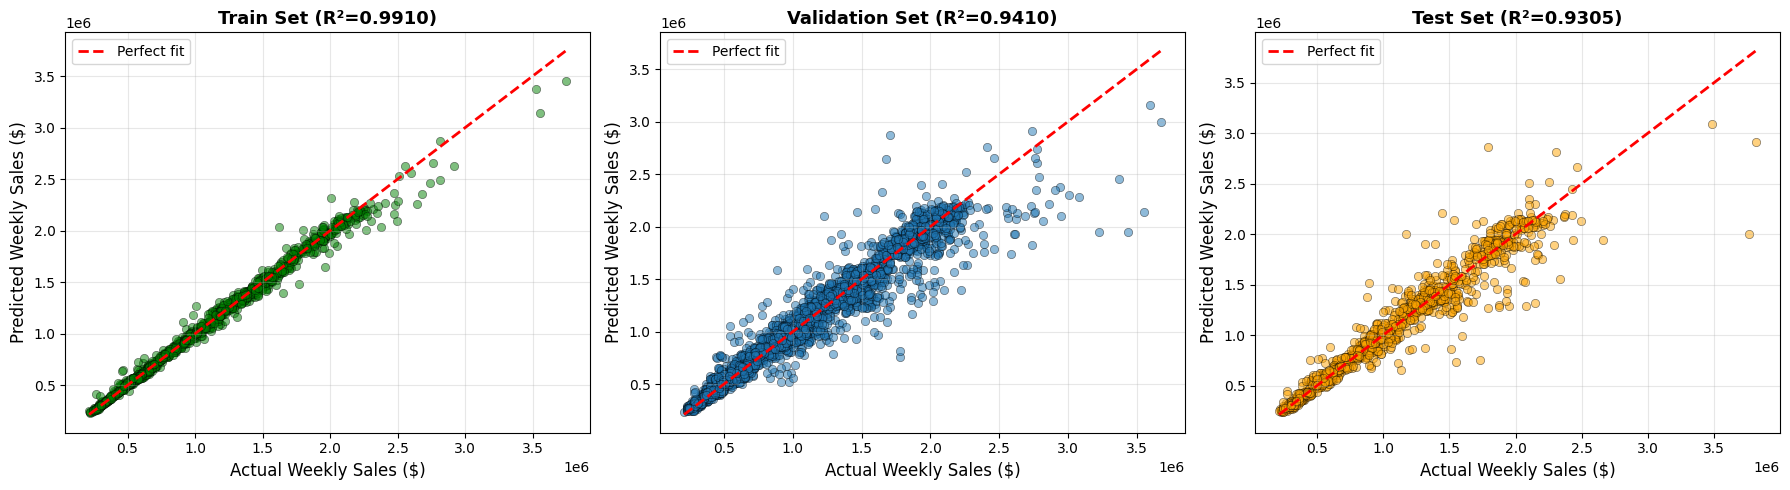

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Train parity plot
axes[0].scatter(y_train, preds_train, alpha=0.5, edgecolors='k', linewidth=0.5, color='green')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Perfect fit')
axes[0].set_xlabel('Actual Weekly Sales ($)', fontsize=12)
axes[0].set_ylabel('Predicted Weekly Sales ($)', fontsize=12)
axes[0].set_title(f"Train Set (R²={metrics['TRAIN']['R2']:.4f})", fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation parity plot
axes[1].scatter(y_val, preds_val, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2, label='Perfect fit')
axes[1].set_xlabel('Actual Weekly Sales ($)', fontsize=12)
axes[1].set_ylabel('Predicted Weekly Sales ($)', fontsize=12)
axes[1].set_title(f"Validation Set (R²={metrics['VAL']['R2']:.4f})", fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Test parity plot
axes[2].scatter(y_test, preds_test, alpha=0.5, edgecolors='k', linewidth=0.5, color='orange')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect fit')
axes[2].set_xlabel('Actual Weekly Sales ($)', fontsize=12)
axes[2].set_ylabel('Predicted Weekly Sales ($)', fontsize=12)
axes[2].set_title(f"Test Set (R²={metrics['TEST']['R2']:.4f})", fontsize=13, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 7) Model Configuration Summary
This section shows:
1. **Selected Features**: The 11 features used to train the model
2. **Hyperparameters**: Random Forest hyperparameters optimized via cross-validation
3. **Feature Importances**: Which features the forest uses most for predictions

**Hyperparameter Selection Methodology:**
- **n_estimators**, **max_depth**, **min_samples_split**, **min_samples_leaf** optimized via **5-fold cross-validation**
- Search space: n_estimators ∈ [50, 100, 200], max_depth ∈ [10, 20, None], min_samples_split ∈ [2, 10], min_samples_leaf ∈ [1, 5]
- Scoring metric: R² (coefficient of determination)
- This systematic approach ensures optimal forest complexity and generalization

**Key Features of Random Forest:**
- **Ensemble of trees**: Averages predictions from multiple trees (reduces variance)
- **More robust than single tree**: Less prone to overfitting
- **Feature importance**: Aggregated across all trees in the forest
- **No scaling needed**: Tree-based models are scale-invariant
- **Better generalization**: Typically outperforms single Decision Trees

In [8]:
print("="*80)
print("RANDOM FOREST REGRESSION MODEL CONFIGURATION SUMMARY")
print("="*80)

# 1) Selected Features
print("\n1. SELECTED FEATURES (11 total):")
print("-" * 80)
for i, feat in enumerate(feature_cols, 1):
    print(f"   {i:2d}. {feat}")

# 2) Hyperparameters
print("\n2. HYPERPARAMETERS (OPTIMIZED VIA CROSS-VALIDATION):")
print("-" * 80)
print("   Model: RandomForestRegressor (sklearn.ensemble.RandomForestRegressor)")
print("   Hyperparameter Optimization:")
print(f"      - Method: GridSearchCV with 5-fold cross-validation")
print(f"      - Search space:")
print(f"          n_estimators ∈ [50, 100, 200]")
print(f"          max_depth ∈ [10, 20, None]")
print(f"          min_samples_split ∈ [2, 10]")
print(f"          min_samples_leaf ∈ [1, 5]")
print(f"      - Scoring metric: R² (coefficient of determination)")
print(f"      - Best n_estimators: {best_params['n_estimators']}")
print(f"      - Best max_depth: {best_params['max_depth']}")
print(f"      - Best min_samples_split: {best_params['min_samples_split']}")
print(f"      - Best min_samples_leaf: {best_params['min_samples_leaf']}")
print(f"      - CV R² score: {cv_score:.4f}")
print("\n   Model Parameters:")
print(f"      - n_estimators: {rf.n_estimators} (OPTIMIZED)")
print(f"      - max_depth: {rf.max_depth} (OPTIMIZED)")
print(f"      - min_samples_split: {rf.min_samples_split} (OPTIMIZED)")
print(f"      - min_samples_leaf: {rf.min_samples_leaf} (OPTIMIZED)")
print(f"      - random_state: {rf.random_state}")
print(f"      - n_jobs: {rf.n_jobs} (parallel processing)")
print("\n   Preprocessing:")
print(f"      - Imputation: SimpleImputer(strategy='median')")
print(f"      - Scaling: None (not required for tree-based models)")
print(f"      - Random seed: 42")

# 3) Feature Importances
print("\n3. FEATURE IMPORTANCES (averaged across all trees):")
print("-" * 80)
print("\n   Feature Importances (sorted by importance):")
for idx, row in feature_importance.iterrows():
    bar_length = int(row['Importance'] * 50)  # Scale to 50 chars max
    bar = '█' * bar_length
    print(f"      {row['Feature']:20s}: {row['Importance']:6.4f}  {bar}")

print("\n" + "="*80)
print("INTERPRETATION:")
print("-" * 80)
print("• Feature importances sum to 1.0")
print(f"• Random Forest with {best_params['n_estimators']} trees averages predictions for robustness")
print("• Higher importance → feature used more often across all trees")
print("• Features with 0 importance were not used by any tree")
print("• Hyperparameters selected via 5-fold CV to balance bias-variance tradeoff")
print(f"• Ensemble averaging reduces overfitting compared to single tree")
print("="*80)

RANDOM FOREST REGRESSION MODEL CONFIGURATION SUMMARY

1. SELECTED FEATURES (11 total):
--------------------------------------------------------------------------------
    1. Holiday_Flag
    2. Temperature
    3. Fuel_Price
    4. CPI
    5. Unemployment
    6. Store_Encoded
    7. Month
    8. DayOfWeek
    9. Week
   10. Quarter
   11. IsWeekend

2. HYPERPARAMETERS (OPTIMIZED VIA CROSS-VALIDATION):
--------------------------------------------------------------------------------
   Model: RandomForestRegressor (sklearn.ensemble.RandomForestRegressor)
   Hyperparameter Optimization:
      - Method: GridSearchCV with 5-fold cross-validation
      - Search space:
          n_estimators ∈ [50, 100, 200]
          max_depth ∈ [10, 20, None]
          min_samples_split ∈ [2, 10]
          min_samples_leaf ∈ [1, 5]
      - Scoring metric: R² (coefficient of determination)
      - Best n_estimators: 200
      - Best max_depth: 20
      - Best min_samples_split: 2
      - Best min_samples_lea

# 8) Reporting Results in Technical Papers

**For academic/technical papers, report:**

1. **Primary Metric**: Test set R² (reported above)
2. **Methodology**: "Random Forest hyperparameters (n_estimators, max_depth, min_samples_split, min_samples_leaf) optimized via 5-fold cross-validation on training set"
3. **Transparency**: Include train/validation/test metrics in a table
4. **Interpretable Units**: RMSE and MAE in dollars (not normalized scale)
5. **Feature Importance**: Report top features identified by the forest

**Example Results Table for Paper:**
```
| Dataset    | R²    | RMSE ($)  | MAE ($)   |
|------------|-------|-----------|-----------||
| Train      | 0.XXX | XX,XXX    | X,XXX     |
| Validation | 0.XXX | XX,XXX    | X,XXX     |
| Test       | 0.XXX | XX,XXX    | X,XXX     |
```
*Optimal hyperparameters: n_estimators=[value], max_depth=[value], min_samples_split=[value], min_samples_leaf=[value] selected via 5-fold CV (CV R² = [value])*  
*Top 3 important features: [feature1], [feature2], [feature3]*

**Key Points:**
- Cross-validation demonstrates systematic hyperparameter search
- Test set never used during training or hyperparameter selection
- Train-validation gap should be smaller than Decision Tree (less overfitting)
- **Random Forest vs Decision Tree**: Forest averages multiple trees for robustness
- **Random Forest vs Linear Models**: Captures non-linear patterns with better generalization
- Feature importances provide interpretability

**When to Use Random Forest:**
- **Random Forest**: When you want robustness and don't need extreme performance (good baseline)
- **Decision Tree**: When you need a simple, interpretable single tree
- **XGBoost/LightGBM**: When you need state-of-the-art performance (gradient boosting)
- **Linear Models**: When relationships are linear or you need coefficient interpretation

**Expected Performance:**
- Random Forest typically achieves **higher R² than Decision Trees and Linear models**
- Can achieve R² = 0.40-0.70 with basic features (vs 0.30-0.60 for Decision Tree, 0.15 for linear)
- More stable predictions (averaging reduces variance)
- Less overfitting than single Decision Trees

**Advantages of Random Forest:**
- ✅ Robust to outliers and noise
- ✅ Handles non-linear relationships
- ✅ Less prone to overfitting than single trees
- ✅ No feature scaling required
- ✅ Built-in feature importance
- ✅ Can handle missing values (with some implementations)
- ❌ Slower to train than single tree (but parallelizable)
- ❌ Less interpretable than single tree